# Chamoli habitation risk triage and site safety

This notebook reproduces the full scoring pipeline from the supplied habitation and candidate-site CSV files. It uses transparent weighted rules so every score can be inspected and challenged. Results are **screening priorities** for expert and field review—not forecasts or automated relocation decisions.

## Method at a glance

- **Habitation risk**: 45% hazard, 30% exposure, 25% vulnerability.
- **Hazard**: landslide, flood, historical events, and slope.
- **Exposure**: population, density, and children aged 0–6.
- **Vulnerability**: housing condition, hospital distance, and healthcare capacity.
- **Candidate sites**: hazard avoidance is weighted most heavily, then road, utilities, health, school, and livelihood access.
- **Confidence**: 50–100 based on completeness of the required source fields.

The input `safe` label is preserved for comparison but is never used to calculate the site score.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import run_pipeline

DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
print(f'Project root: {PROJECT_ROOT}')

Project root: C:\Users\rdhak\Documents\Codex\2026-08-27\exploration-ipynb-x20\ai-ml


In [2]:
# Regenerate all derived data and JSON outputs from the source CSV files.
habitations, sites = run_pipeline(DATA_DIR, OUTPUT_DIR)

print(f'Habitations scored: {len(habitations):,}')
print(f'Candidate sites scored: {len(sites):,}')
habitations[['village_name', 'risk_score', 'triage_level', 'confidence_score']].head()

Habitations scored: 1,170
Candidate sites scored: 20


,village_name,risk_score,triage_level,confidence_score
0,Banswara Chak sainti,39.53,Moderate,100.0
1,Ala chak bura,45.76,Moderate,100.0
2,Amkheth,43.86,Moderate,100.0
3,Anagoli,40.94,Moderate,100.0
4,Angthala,39.55,Moderate,100.0


In [3]:
# Data-quality review: only original source fields are assessed here.
missing = (
    habitations.isna().mean().mul(100).rename('missing_pct').to_frame()
    .query('missing_pct > 0').sort_values('missing_pct', ascending=False)
)
missing

,missing_pct
elevation_m,6.837607
population_density_per_km2,0.598291
temporary_house_pct,0.512821
dilapidated_house_pct,0.512821


In [4]:
# Priority portfolio by operational triage band.
triage_summary = (
    habitations.groupby('triage_level', observed=False)
    .agg(habitations=('habitation_id', 'count'), mean_risk=('risk_score', 'mean'))
    .reindex(['Critical', 'High', 'Moderate', 'Low'])
)
triage_summary

,habitations,mean_risk
triage_level,,
Critical,16,56.860625
High,205,50.279902
Moderate,680,42.938074
Low,269,34.079703


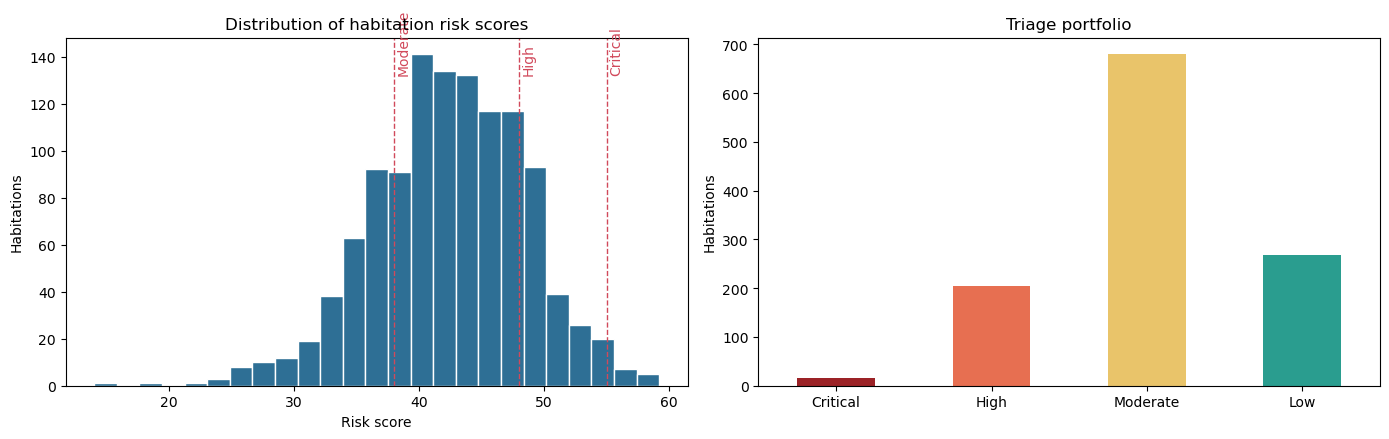

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

habitations['risk_score'].plot.hist(bins=25, ax=axes[0], color='#2E6F95', edgecolor='white')
for cut, label in [(38, 'Moderate'), (48, 'High'), (55, 'Critical')]:
    axes[0].axvline(cut, color='#D1495B', linestyle='--', linewidth=1)
    axes[0].text(cut + .2, axes[0].get_ylim()[1] * .9, label, rotation=90, color='#D1495B')
axes[0].set(title='Distribution of habitation risk scores', xlabel='Risk score', ylabel='Habitations')

order = ['Critical', 'High', 'Moderate', 'Low']
triage_summary.loc[order, 'habitations'].plot.bar(ax=axes[1], color=['#9B2226', '#E76F51', '#E9C46A', '#2A9D8F'])
axes[1].set(title='Triage portfolio', xlabel='', ylabel='Habitations')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()

In [6]:
# Highest-priority cases, with the score explanation used for review.
priority_columns = [
    'habitation_id', 'village_name', 'population', 'hazard_component',
    'exposure_component', 'vulnerability_component', 'risk_score',
    'triage_level', 'confidence_score', 'explanation'
]
habitations.sort_values('risk_score', ascending=False)[priority_columns].head(15)

,habitation_id,village_name,population,hazard_component,exposure_component,vulnerability_component,risk_score,triage_level,confidence_score,explanation
145,40957,Naurakh,1574,68.40,85.63,10.91,59.20,Critical,100.0,"Key drivers: high composite hazard (68.4), ste..."
469,40841,Langsi,395,75.15,69.91,14.65,58.45,Critical,100.0,"Key drivers: high composite hazard (75.2), ste..."
448,40840,Gulabkoti,356,75.08,68.42,15.42,58.17,Critical,100.0,"Key drivers: high composite hazard (75.1), ste..."
162,41078,Ramani,1076,65.85,80.72,16.41,57.95,Critical,100.0,"Key drivers: high composite hazard (65.8), ste..."
488,40813,Pandukaswar,1396,65.15,85.26,10.89,57.62,Critical,100.0,"Key drivers: high composite hazard (65.2), ste..."
6,40986,Bachher,1097,66.90,80.49,12.19,57.30,Critical,100.0,"Key drivers: high composite hazard (66.9), ste..."
512,40817,Urgam,1549,59.00,85.32,20.21,57.20,Critical,100.0,"Key drivers: steep terrain (42.2°), repeated r..."
874,41776,Balan,732,63.75,76.10,21.47,56.88,Critical,100.0,"Key drivers: high composite hazard (63.8), ste..."
123,40908,Mandal,452,66.90,72.29,20.08,56.81,Critical,100.0,"Key drivers: high composite hazard (66.9), ste..."
905,41800,Chaud,649,59.45,78.34,24.84,56.46,Critical,100.0,"Key drivers: steep terrain (41.6°), repeated r..."


In [7]:
# Candidate sites: compare calculated screening tier against the provided safe flag.
site_columns = [
    'site_id', 'site_name', 'hazard_score', 'road_access', 'livelihood_access',
    'site_safety_score', 'site_tier', 'safe', 'confidence_score', 'explanation'
]
sites.sort_values('site_safety_score', ascending=False)[site_columns]

,site_id,site_name,hazard_score,road_access,livelihood_access,site_safety_score,site_tier,safe,confidence_score,explanation
8,S009,Candidate - Dimar,51.74,80,77,75.75,Preferred,False,100.0,"Preferred site: strong road access, good livel..."
0,S001,Candidate - Uttaraun,47.74,95,88,75.58,Preferred,True,100.0,"Preferred site: lower relative hazard, strong ..."
17,S018,Candidate - Paini,52.54,80,77,75.43,Preferred,False,100.0,"Preferred site: strong road access, good livel..."
5,S006,Candidate - Batula,46.94,80,73,75.07,Preferred,True,100.0,"Preferred site: lower relative hazard, strong ..."
12,S013,Candidate - Bainoli,46.14,80,64,72.54,Preferred,True,100.0,"Preferred site: lower relative hazard, strong ..."
10,S011,Candidate - Kanda Maikhura,52.54,65,80,71.95,Preferred,False,100.0,"Preferred site: good livelihood access, health..."
18,S019,Candidate - Hailang,51.34,80,68,70.33,Preferred,False,100.0,Preferred site: strong road access.
1,S002,Candidate - Umrakot Urf Baidanu,47.34,95,79,69.65,Preferred,True,100.0,"Preferred site: lower relative hazard, strong ..."
2,S003,Candidate - Langasu,52.14,95,83,67.85,Preferred,False,100.0,"Preferred site: strong road access, good livel..."
4,S005,Candidate - Bangaon Talla,49.74,60,83,64.85,Preferred,True,100.0,"Preferred site: lower relative hazard, good li..."


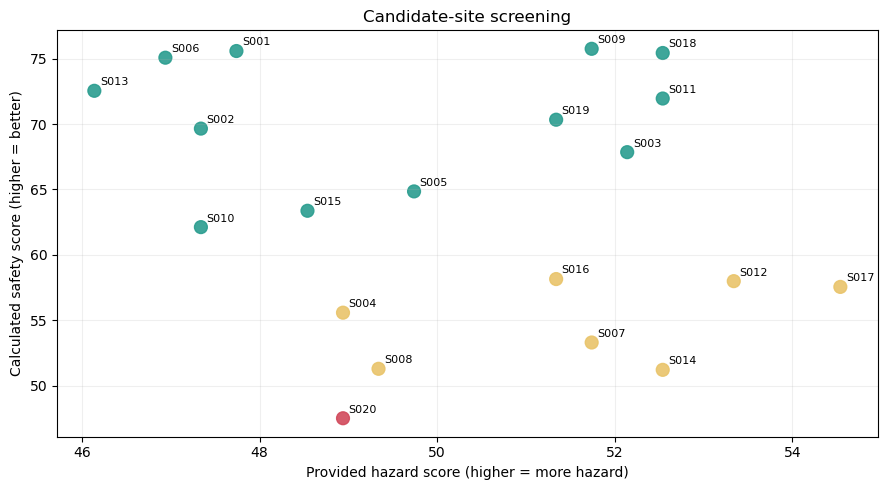

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = sites['site_tier'].map({'Preferred': '#2A9D8F', 'Conditional': '#E9C46A', 'Avoid': '#D1495B'})
ax.scatter(sites['hazard_score'], sites['site_safety_score'], s=85, c=colors, alpha=.9)
for _, row in sites.iterrows():
    ax.annotate(row['site_id'], (row['hazard_score'], row['site_safety_score']), xytext=(4, 4), textcoords='offset points', fontsize=8)
ax.set(title='Candidate-site screening', xlabel='Provided hazard score (higher = more hazard)', ylabel='Calculated safety score (higher = better)')
ax.grid(alpha=.2)
plt.tight_layout()

## Interpretation and next steps

1. Start field verification with `Critical` and `High` habitations, treating the explanation as a checklist of data to verify.
2. Treat a `Preferred` or `Conditional` candidate site as a shortlist only. Confirm geotechnical conditions, land rights, environmental constraints, social acceptance, water reliability, and actual service capacity on the ground.
3. Investigate disagreement between the supplied `safe` label and the calculated site tier before making any recommendation.
4. Refresh the 2009 habitation demographics and hazard history before operational use.

The exported JSON files are in `outputs/habitation_scores.json` and `outputs/site_scores.json`.